# EDA

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
from wordcloud import WordCloud
from collections import Counter


In [2]:
# Load the dataset
# data = pd.read_csv('political_bias.csv', dtype=str) dont know why this doesnt work 
data = pd.read_csv('political_bias.csv')

In [3]:
# Basic info about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3458 entries, 0 to 3457
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   3458 non-null   object
 1   Link    3458 non-null   object
 2   Text    3397 non-null   object
 3   Source  3458 non-null   object
 4   Bias    3458 non-null   object
dtypes: object(5)
memory usage: 135.2+ KB


In [4]:
# Checking for missing values
missing_values = data.isnull().sum()
print(missing_values)

Title      0
Link       0
Text      61
Source     0
Bias       0
dtype: int64


In [5]:
# Drop rows with any null (NaN) values
data = data.dropna()

# Verify by checking the data info
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3397 entries, 0 to 3457
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   3397 non-null   object
 1   Link    3397 non-null   object
 2   Text    3397 non-null   object
 3   Source  3397 non-null   object
 4   Bias    3397 non-null   object
dtypes: object(5)
memory usage: 159.2+ KB


In [6]:
# Drop rows where 'Text' column contains 'Error fetching article'
data = data[data['Text'] != 'Error fetching article']

# Verify by checking the data info
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2765 entries, 0 to 3457
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   2765 non-null   object
 1   Link    2765 non-null   object
 2   Text    2765 non-null   object
 3   Source  2765 non-null   object
 4   Bias    2765 non-null   object
dtypes: object(5)
memory usage: 129.6+ KB


In [7]:
# Clean the data to fix encoding issues and remove unwanted characters
def fix_encoding_and_special_chars(text):
    # Fix common encoding issues
    text = text.replace('â€™', '').replace('â€œ', '"').replace('â€', '"').replace('â€™','"').replace('â€˜','"')  # Replace known encoding issues
    
    # Remove special characters and numbers using regular expression (keeps only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    return text

# Apply the function to clean the cols
data['Title'] = data['Title'].apply(fix_encoding_and_special_chars)
data['Text'] = data['Text'].apply(fix_encoding_and_special_chars)
data['Source'] = data['Source'].apply(fix_encoding_and_special_chars)
data['Bias'] = data['Bias'].apply(fix_encoding_and_special_chars)

# Convert the data to strings 
data['Title'] = data['Title'].astype('string')
data['Text'] = data['Text'].astype('string')
data['Link'] = data['Link'].astype('string')
data['Source'] = data['Source'].astype('string')
data['Bias'] = data['Bias'].astype('string')

# Verify by checking the data info
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2765 entries, 0 to 3457
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   2765 non-null   string
 1   Link    2765 non-null   string
 2   Text    2765 non-null   string
 3   Source  2765 non-null   string
 4   Bias    2765 non-null   string
dtypes: string(5)
memory usage: 129.6 KB


In [8]:
# Show the first few rows of the dataset
data.head()

,Title,Link,Text,Source,Bias
0,John Boltons Advice for the Continuing Turmoil...,https://thedispatch.com/article/john-boltons-a...,With just days until his inauguration it would...,TheDispatch,lean right
1,Why Shrubland Makes Southern Californias Wildf...,https://thedispatch.com/newsletter/techne/why-...,Welcome back to Techne In Star Trek writers go...,TheDispatch,lean right
2,Los Angeles Destruction Was Fueled by Bad Poli...,https://thedispatch.com/newsletter/capitolism/...,As fire still rages in the Los Angeles area Iv...,TheDispatch,lean right
3,Acquiring Greenland Is a Good Idea Threatening...,https://thedispatch.com/article/acquiring-gree...,Whether it was Will Rogers or Tony Soprano the...,TheDispatch,lean right
4,Assessing Trumps Expansionist Designs,https://thedispatch.com/newsletter/morning/ass...,Happy Friday If anyone was wondering Belgiums ...,TheDispatch,lean right


In [9]:
# Summary statistics of numerical columns (if any)
data.describe()

,Title,Link,Text,Source,Bias
count,2765,2765,2765,2765,2765
unique,2511,2280,2434,21,5
top,Trumps Supposed Unity Message Is a Gloating Th...,https://www.thenation.com/article/politics/dem...,A new bill in Mississippi could turn bounty hu...,Alternet,left
freq,7,7,5,596,1376


In [10]:
# noticed that not all rows are unique, so we will drop duplicates
data = data.drop_duplicates(subset='Title', keep='first')
data = data.drop_duplicates(subset='Text', keep='first')
data = data.drop_duplicates(subset='Link', keep='first')

In [11]:
# Verify by checking the data info
data.describe()

,Title,Link,Text,Source,Bias
count,2224,2224,2224,2224,2224
unique,2224,2224,2224,21,5
top,John Boltons Advice for the Continuing Turmoil...,https://thedispatch.com/article/john-boltons-a...,With just days until his inauguration it would...,Alternet,left
freq,1,1,1,483,1150


## Distribution of Bias over dataset

In [12]:
# Checking the distribution of the 'Bias' column
bias_counts = data['Bias'].value_counts()
print(bias_counts)
# over representation of left bias

Bias
left          1150
right          382
lean left      305
center         202
lean right     185
Name: count, dtype: Int64


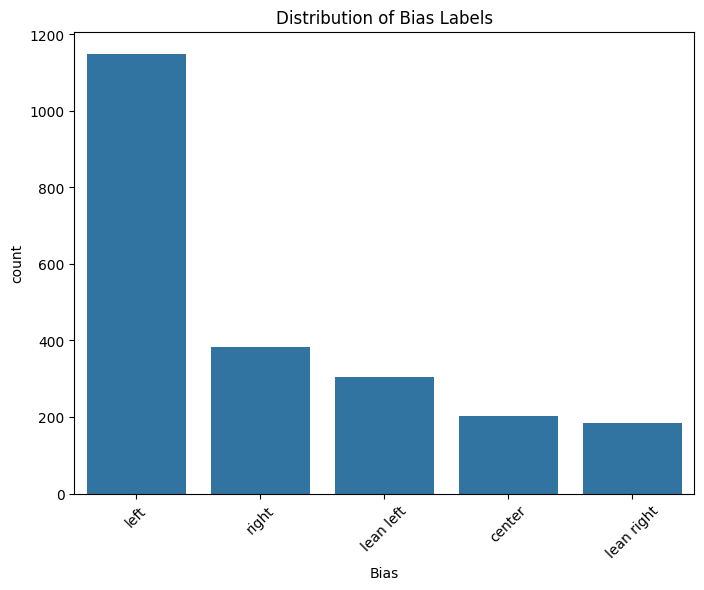

In [13]:
# Visualizing the distribution of Bias labels
plt.figure(figsize=(8,6))
sns.countplot(data=data, x='Bias', order=data['Bias'].value_counts().index)
plt.title('Distribution of Bias Labels')
plt.xticks(rotation=45)
plt.show()

## Analyse Text Content 

In [14]:
import nltk
from nltk.corpus import stopwords

# Download NLTK stopwords
nltk.download('stopwords')

# Get the set of English stopwords
stop_words = set(stopwords.words('english'))

# Updated clean_text function to remove punctuation and stopwords
def clean_text(text):
    text = text.lower()  # Convert text to lowercase
    text = ''.join([char for char in text if char not in string.punctuation])  # Remove punctuation
    words = text.split()  # Split text into words
    text = ' '.join([word for word in words if word not in stop_words]) # Remove stopwords
    return text

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/foongming/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
# Apply the clean_text function to the 'Text' column
data['cleaned_text'] = data['Text'].apply(clean_text)

# Most common words (excluding stopwords)
words = ' '.join(data['cleaned_text']).split()
word_counts = Counter(words)
most_common_words = word_counts.most_common(20)

# Display the 20 most common words
common_words_df = pd.DataFrame(most_common_words, columns=['Word', 'Frequency'])
common_words_df

,Word,Frequency
0,trump,9649
1,said,8341
2,president,4765
3,us,4118
4,people,3468
5,trumps,3419
6,would,3336
7,also,3076
8,one,2862
9,new,2656


In [16]:
total_words = sum(word_counts.values())
print(total_words)

850684


In [17]:
common_words_df['Percentage'] = (common_words_df['Frequency'] / total_words) * 100

In [18]:
common_words_df.head(20)

,Word,Frequency,Percentage
0,trump,9649,1.134264
1,said,8341,0.980505
2,president,4765,0.560137
3,us,4118,0.484081
4,people,3468,0.407672
5,trumps,3419,0.401912
6,would,3336,0.392155
7,also,3076,0.361591
8,one,2862,0.336435
9,new,2656,0.312219


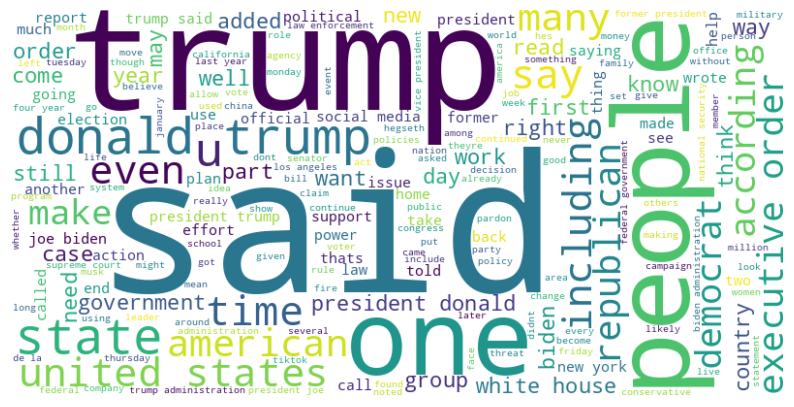

In [19]:
# Generate a wordcloud
text = ' '.join(data['cleaned_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


## Analyse Length

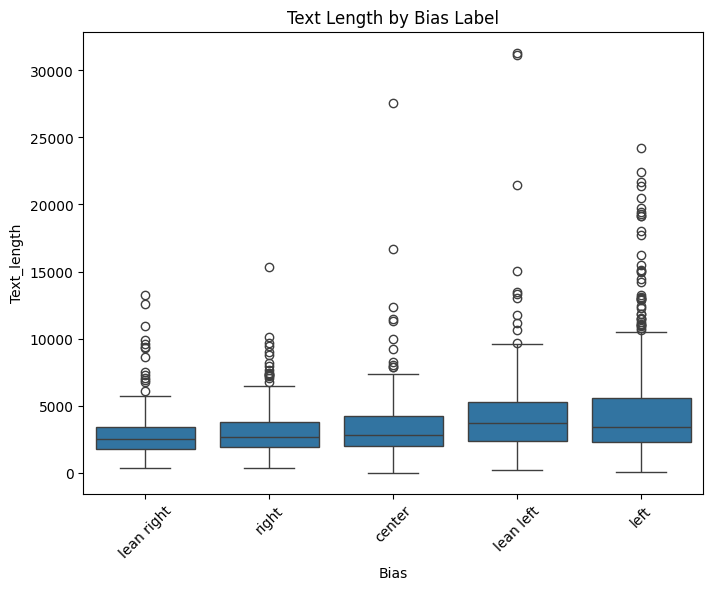

In [20]:
# Investigating length of articles by bias
data['Text_length'] = data['Text'].apply(len)

plt.figure(figsize=(8,6))
sns.boxplot(data=data, x='Bias', y='Text_length')
plt.title('Text Length by Bias Label')
plt.xticks(rotation=45)
plt.show()

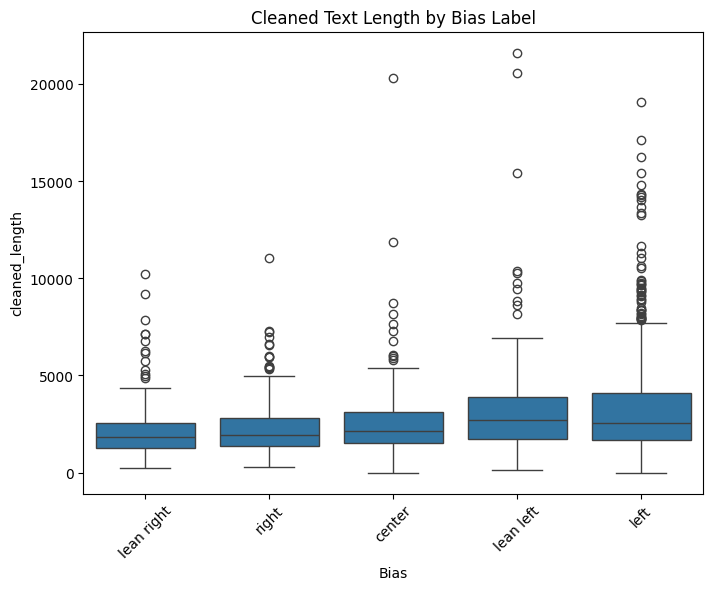

In [21]:
# Investigating length of cleaned articles by bias
data['cleaned_length'] = data['cleaned_text'].apply(len)

plt.figure(figsize=(8,6))
sns.boxplot(data=data, x='Bias', y='cleaned_length')
plt.title('Cleaned Text Length by Bias Label')
plt.xticks(rotation=45)
plt.show()

In [22]:
# Group by 'Bias' and get text length analysis for each group
grouped_description = data.groupby('Bias').describe()

# Display the result
print(grouped_description)

           Text_length                                                    \
                 count         mean          std    min      25%     50%   
Bias                                                                       
center           202.0  3550.292079  2859.330496    3.0  2018.75  2785.5   
lean left        305.0  4288.947541  3396.918928  177.0  2357.00  3671.0   
lean right       185.0  2988.097297  2169.002348  348.0  1790.00  2499.0   
left            1150.0  4253.715652  3020.431239   15.0  2268.75  3421.0   
right            382.0  3030.094241  1757.916638  363.0  1886.75  2625.0   

                             cleaned_length                                   \
                75%      max          count         mean          std    min   
Bias                                                                           
center      4218.25  27565.0          202.0  2630.940594  2068.903448    0.0   
lean left   5289.00  31337.0          305.0  3122.101639  2387.098945  

In [23]:
## i think we should drop the outlier data. wdyt? can wait till new data is in 

In [24]:
import scipy.stats as stats

# Perform ANOVA to compare the means of cleaned_length across different Bias categories
f_stat, p_val = stats.f_oneway(data[data['Bias'] == 'lean right']['cleaned_length'],
                                data[data['Bias'] == 'right']['cleaned_length'],
                                data[data['Bias'] == 'center']['cleaned_length'],
                                data[data['Bias'] == 'lean left']['cleaned_length'],
                                data[data['Bias'] == 'left']['cleaned_length'])

print("ANOVA p-value:", p_val)

#statistically significant difference in the means of text lengths between the different bias categories

ANOVA p-value: 4.123550054996605e-18


In [25]:
# Perform Levene's test to compare the variances of cleaned_length across different Bias categories
w_stat, p_val_levene = stats.levene(data[data['Bias'] == 'lean right']['cleaned_length'],
                                    data[data['Bias'] == 'right']['cleaned_length'],
                                    data[data['Bias'] == 'center']['cleaned_length'],
                                    data[data['Bias'] == 'lean left']['cleaned_length'],
                                    data[data['Bias'] == 'left']['cleaned_length'])

print("Levene's Test p-value:", p_val_levene)

#statistically significant difference in the variance of text lengths between the different bias categories

Levene's Test p-value: 1.820315606233501e-11


## Analyse Distribution of Vocabulary

In [26]:
from collections import Counter

# Dictionary to store unique word count for each Bias label
unique_word_counts = {}

# Iterate through unique Bias labels
for bias_label in data['Bias'].unique():
    # Concatenate all cleaned_text for the current bias label
    all_text = " ".join(data[data['Bias'] == bias_label]['cleaned_text'])
    
    # Get unique words
    unique_words = set(all_text.split())
    
    # Store the count in the dictionary
    unique_word_counts[bias_label] = len(unique_words)

# Sort the dictionary by values in descending order
sorted_unique_word_counts = dict(sorted(unique_word_counts.items(), key=lambda item: item[1], reverse=True))

# Print the sorted dictionary
print(sorted_unique_word_counts)

{'left': 37739, 'lean left': 14873, 'right': 14591, 'center': 11724, 'lean right': 11333}


In [27]:
# Function to compute unique word count for each row
def unique_word_count(text):
    return len(set(str(text).split()))

# Add a new column for per-row unique word count
data['unique_word_count'] = data['cleaned_text'].apply(unique_word_count)

# Display the first few rows of the updated DataFrame
data.head()

,Title,Link,Text,Source,Bias,cleaned_text,Text_length,cleaned_length,unique_word_count
0,John Boltons Advice for the Continuing Turmoil...,https://thedispatch.com/article/john-boltons-a...,With just days until his inauguration it would...,TheDispatch,lean right,days inauguration would shock learn donald tru...,6060,4159,380
1,Why Shrubland Makes Southern Californias Wildf...,https://thedispatch.com/newsletter/techne/why-...,Welcome back to Techne In Star Trek writers go...,TheDispatch,lean right,welcome back techne star trek writers got arou...,12568,9201,769
2,Los Angeles Destruction Was Fueled by Bad Poli...,https://thedispatch.com/newsletter/capitolism/...,As fire still rages in the Los Angeles area Iv...,TheDispatch,lean right,fire still rages los angeles area ive torn whe...,2049,1465,169
3,Acquiring Greenland Is a Good Idea Threatening...,https://thedispatch.com/article/acquiring-gree...,Whether it was Will Rogers or Tony Soprano the...,TheDispatch,lean right,whether rogers tony soprano old suggestion buy...,4263,3073,309
4,Assessing Trumps Expansionist Designs,https://thedispatch.com/newsletter/morning/ass...,Happy Friday If anyone was wondering Belgiums ...,TheDispatch,lean right,happy friday anyone wondering belgiums food ag...,452,351,48


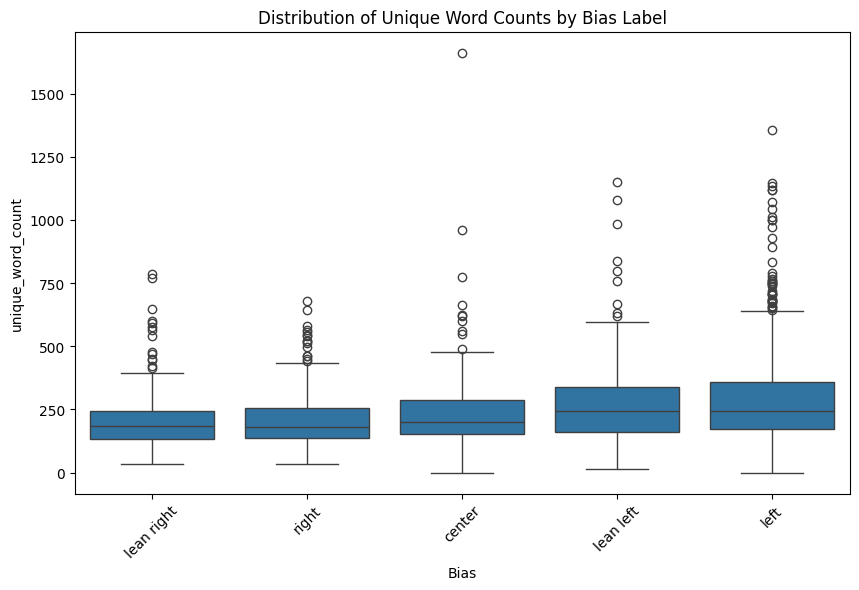

In [ ]:
# Visualize distributions
plt.figure(figsize=(10,6))
sns.boxplot(x=data['Bias'], y=data['unique_word_count'])
plt.xticks(rotation=45)
plt.title("Distribution of Unique Word Counts by Bias Label")
plt.show()

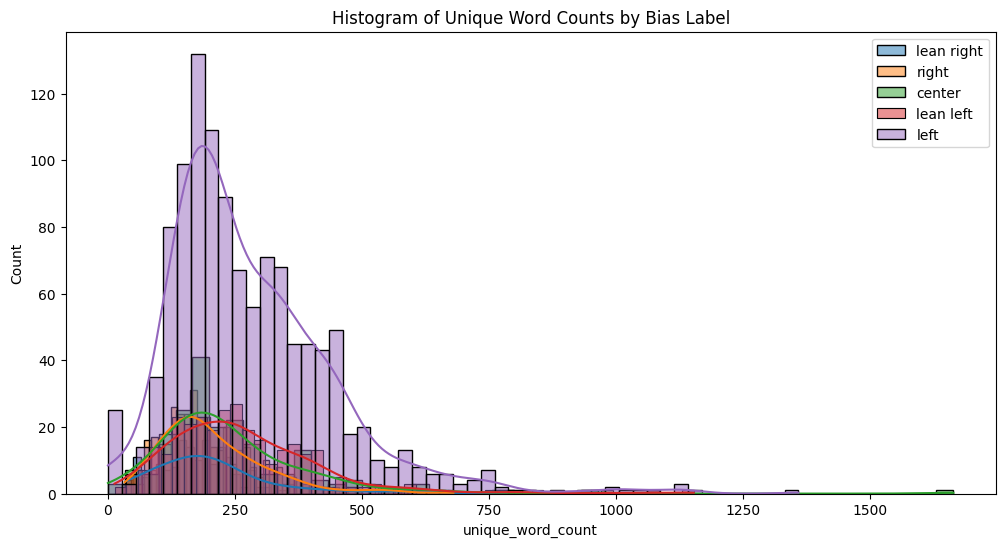

In [29]:
plt.figure(figsize=(12,6))
for bias_label in data['Bias'].unique():
    sns.histplot(data[data['Bias'] == bias_label]['unique_word_count'], kde=True, label=bias_label, bins=50)
plt.legend()
plt.title("Histogram of Unique Word Counts by Bias Label")
plt.show()

conc of analysis of vocabularly - from box whisker and histogram, unlikely to be a strong predictor

conclusion of checking text length: 
- right articles are shorter, while left are longer. 
- difference in mean length and variances between each bias is significant (anova and levene tests are significant at p<0.05)
- length is potentially a predictor of bias. 

## Analyse Source

Source
Alternet                    483
Apnews                      390
BreitBart                   221
NewYorkPost                 132
Huffpost                    128
usatoday                     97
reason                       88
StraightArrowNews            81
abcnews                      77
npr                          75
IndependentJournalReview     72
MotherJones                  59
TheDailyBeast                59
nbcnews                      56
TheFederalist                40
TheFreePress                 36
BlazeMedia                   35
cnbc                         33
TheNation                    31
TheDispatch                  17
TheWashingtonFreeBeacon      14
Name: count, dtype: Int64


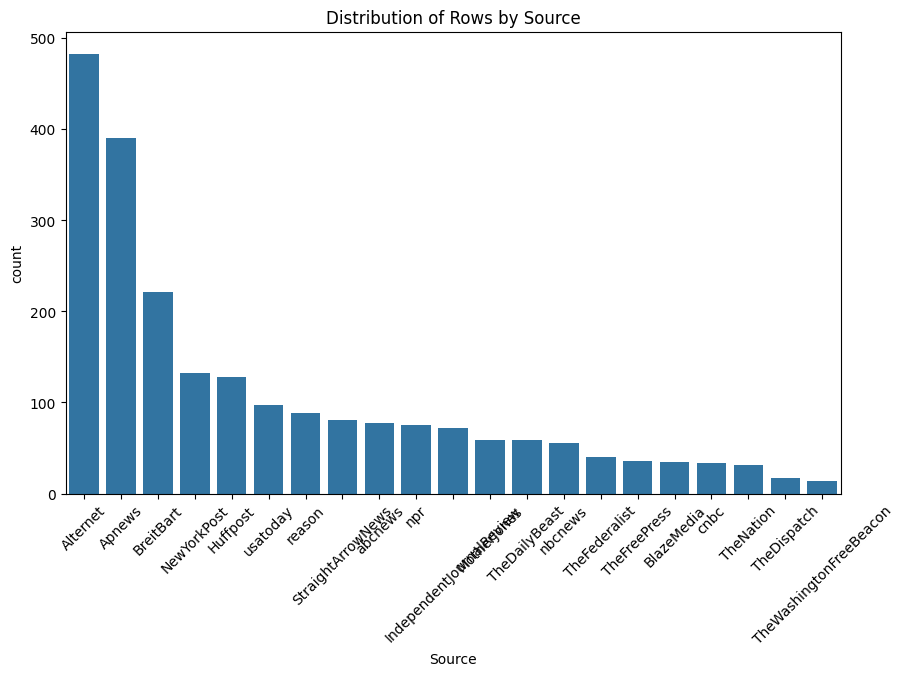

In [31]:
## check distribution of news sources
source_counts = data['Source'].value_counts()

# Print the distribution
print(source_counts)

# Plot the distribution using a bar plot
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Source', order=source_counts.index)
plt.title('Distribution of Rows by Source')
plt.xticks(rotation=45)
plt.show()

Bias                      center  lean left  lean right  left  right
Source                                                              
Alternet                       0          0           0   483      0
Apnews                         0          0           0   390      0
BreitBart                      0          0           0     0    221
NewYorkPost                    0          0         132     0      0
Huffpost                       0          0           0   128      0
usatoday                       0         97           0     0      0
reason                        88          0           0     0      0
StraightArrowNews             81          0           0     0      0
abcnews                        0         77           0     0      0
npr                            0         75           0     0      0
IndependentJournalReview       0          0           0     0     72
MotherJones                    0          0           0    59      0
TheDailyBeast                  0  

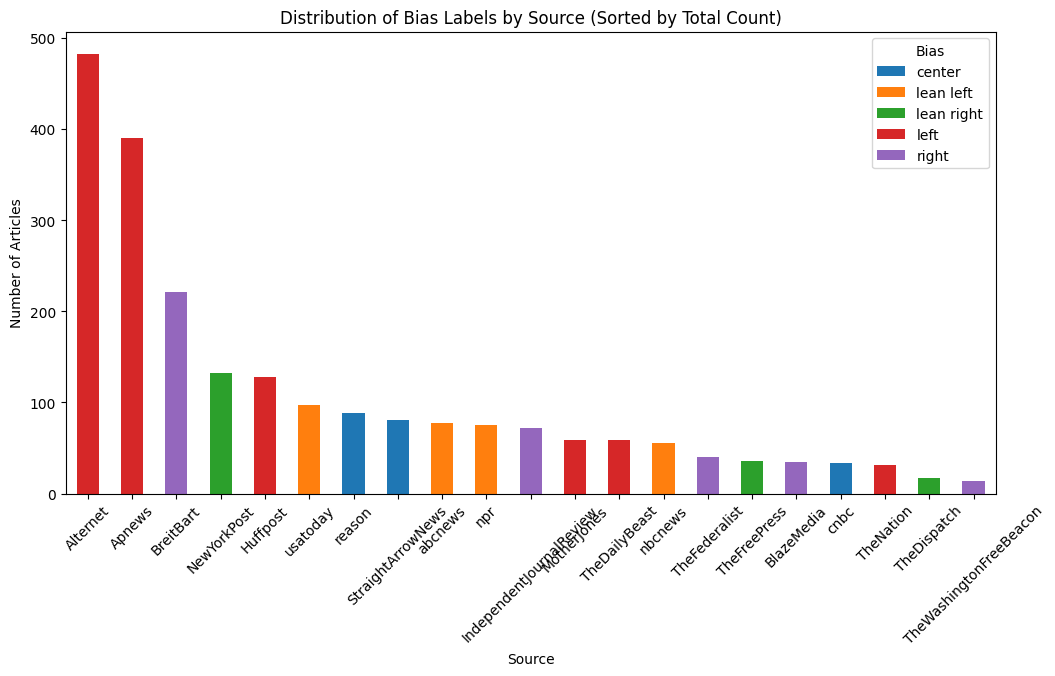

In [32]:
# Group by 'Source' and 'Bias' and get the count for each combination
bias_distribution_by_source = data.groupby(['Source', 'Bias']).size().unstack(fill_value=0)

# Sum the counts for each source and sort by the total count
bias_distribution_by_source['Total'] = bias_distribution_by_source.sum(axis=1)
bias_distribution_by_source = bias_distribution_by_source.sort_values(by='Total', ascending=False)

# Drop the 'Total' column from the plot
bias_distribution_by_source.drop('Total', axis=1, inplace=True)

# Print the sorted distribution
print(bias_distribution_by_source)

# Plot the distribution using a stacked bar plot
bias_distribution_by_source.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Distribution of Bias Labels by Source (Sorted by Total Count)')
plt.xlabel('Source')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.legend(title='Bias')
plt.show()

Bias                      center  lean left  lean right   left  right
Source                                                               
Alternet                     0.0        0.0         0.0  100.0    0.0
TheFederalist                0.0        0.0         0.0    0.0  100.0
reason                     100.0        0.0         0.0    0.0    0.0
npr                          0.0      100.0         0.0    0.0    0.0
nbcnews                      0.0      100.0         0.0    0.0    0.0
cnbc                       100.0        0.0         0.0    0.0    0.0
abcnews                      0.0      100.0         0.0    0.0    0.0
TheWashingtonFreeBeacon      0.0        0.0         0.0    0.0  100.0
TheNation                    0.0        0.0         0.0  100.0    0.0
TheFreePress                 0.0        0.0       100.0    0.0    0.0
TheDispatch                  0.0        0.0       100.0    0.0    0.0
Apnews                       0.0        0.0         0.0  100.0    0.0
TheDailyBeast       

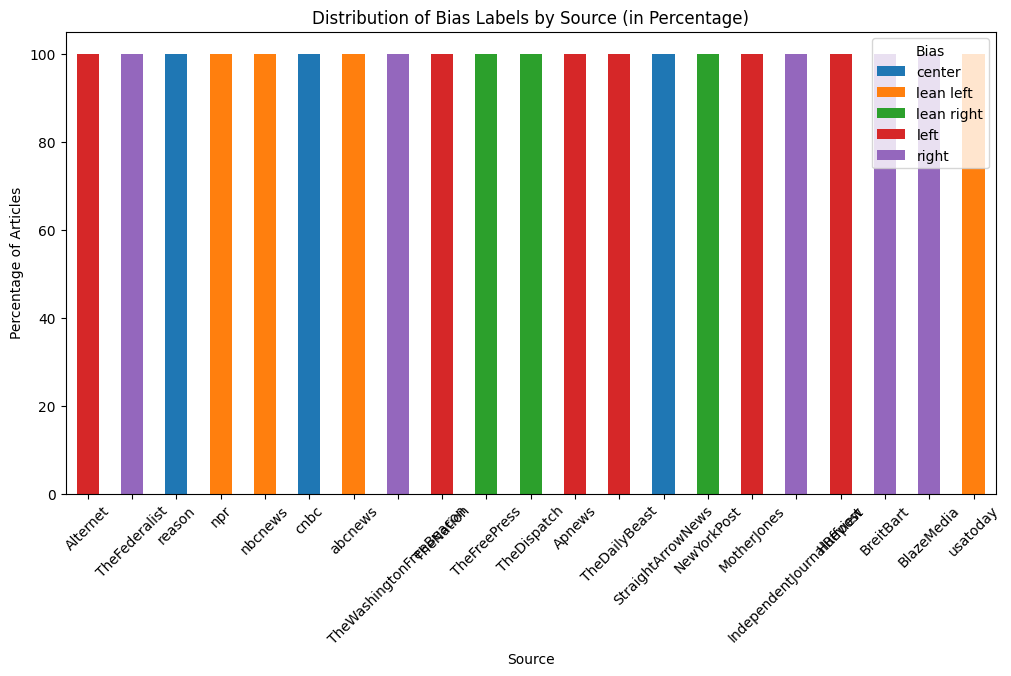

In [33]:
# Group by 'Source' and 'Bias' and get the count for each combination
bias_distribution_by_source = data.groupby(['Source', 'Bias']).size().unstack(fill_value=0)

# Normalize the counts by dividing by the row sums (to get percentages)
bias_distribution_by_source = bias_distribution_by_source.div(bias_distribution_by_source.sum(axis=1), axis=0) * 100

# Sort by the total percentage (optional, to maintain consistency)
bias_distribution_by_source['Total'] = bias_distribution_by_source.sum(axis=1)
bias_distribution_by_source = bias_distribution_by_source.sort_values(by='Total', ascending=False)

# Drop the 'Total' column from the plot
bias_distribution_by_source.drop('Total', axis=1, inplace=True)

# Print the normalized distribution
print(bias_distribution_by_source)

# Plot the distribution using a stacked column chart in percentages
bias_distribution_by_source.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Distribution of Bias Labels by Source (in Percentage)')
plt.xlabel('Source')
plt.ylabel('Percentage of Articles')
plt.xticks(rotation=45)
plt.legend(title='Bias')
plt.show()

# all sources produce only one type of bias, hence source is a strong predictor of bias

In [34]:
# Create a set of unique words from the 'Source' column
unique_words = set(" ".join(data['Source']).split())

# Remove 'reason' if it exists in the set
unique_words.discard('reason')

# Function to remove words in unique_words from text
def strip_words(text, words_to_remove):
    return " ".join([word for word in text.split() if word not in words_to_remove])

# Create a new DataFrame and apply the stripping function
df_stripped_source_names = data.copy()
df_stripped_source_names['stripped_text'] = df_stripped_source_names['cleaned_text'].apply(lambda x: strip_words(str(x), unique_words))

# Add stripped_len column for the length of stripped_text
df_stripped_source_names['stripped_len'] = df_stripped_source_names['stripped_text'].apply(lambda x: len(x.split()))

# Add a new column for the difference between text_length and stripped_len
df_stripped_source_names['text_length_diff'] = df_stripped_source_names['Text_length'] - df_stripped_source_names['stripped_len']

# Display the new DataFrame
df_stripped_source_names.head()

,Title,Link,Text,Source,Bias,cleaned_text,Text_length,cleaned_length,unique_word_count,stripped_text,stripped_len,text_length_diff
0,John Boltons Advice for the Continuing Turmoil...,https://thedispatch.com/article/john-boltons-a...,With just days until his inauguration it would...,TheDispatch,lean right,days inauguration would shock learn donald tru...,6060,4159,380,days inauguration would shock learn donald tru...,534,5526
1,Why Shrubland Makes Southern Californias Wildf...,https://thedispatch.com/newsletter/techne/why-...,Welcome back to Techne In Star Trek writers go...,TheDispatch,lean right,welcome back techne star trek writers got arou...,12568,9201,769,welcome back techne star trek writers got arou...,1171,11397
2,Los Angeles Destruction Was Fueled by Bad Poli...,https://thedispatch.com/newsletter/capitolism/...,As fire still rages in the Los Angeles area Iv...,TheDispatch,lean right,fire still rages los angeles area ive torn whe...,2049,1465,169,fire still rages los angeles area ive torn whe...,192,1857
3,Acquiring Greenland Is a Good Idea Threatening...,https://thedispatch.com/article/acquiring-gree...,Whether it was Will Rogers or Tony Soprano the...,TheDispatch,lean right,whether rogers tony soprano old suggestion buy...,4263,3073,309,whether rogers tony soprano old suggestion buy...,410,3853
4,Assessing Trumps Expansionist Designs,https://thedispatch.com/newsletter/morning/ass...,Happy Friday If anyone was wondering Belgiums ...,TheDispatch,lean right,happy friday anyone wondering belgiums food ag...,452,351,48,happy friday anyone wondering belgiums food ag...,48,404


In [35]:
unique_words

{'Alternet',
 'Apnews',
 'BlazeMedia',
 'BreitBart',
 'Huffpost',
 'IndependentJournalReview',
 'MotherJones',
 'NewYorkPost',
 'StraightArrowNews',
 'TheDailyBeast',
 'TheDispatch',
 'TheFederalist',
 'TheFreePress',
 'TheNation',
 'TheWashingtonFreeBeacon',
 'abcnews',
 'cnbc',
 'nbcnews',
 'npr',
 'usatoday'}

In [36]:
# Display the top 50 rows with selected columns
df_stripped_source_names[['cleaned_text', 'Text_length', 'stripped_text', 'stripped_len']].head(50)

,cleaned_text,Text_length,stripped_text,stripped_len
0,days inauguration would shock learn donald tru...,6060,days inauguration would shock learn donald tru...,534
1,welcome back techne star trek writers got arou...,12568,welcome back techne star trek writers got arou...,1171
2,fire still rages los angeles area ive torn whe...,2049,fire still rages los angeles area ive torn whe...,192
3,whether rogers tony soprano old suggestion buy...,4263,whether rogers tony soprano old suggestion buy...,410
4,happy friday anyone wondering belgiums food ag...,452,happy friday anyone wondering belgiums food ag...,48
5,americans celebrating end prosecutorial nightm...,2893,americans celebrating end prosecutorial nightm...,266
6,newly inaugurated president donald trump made ...,2528,newly inaugurated president donald trump made ...,241
7,former congresswoman liz cheney rwyo responded...,1799,former congresswoman liz cheney rwyo responded...,181
8,former president joe biden issued controversia...,2556,former president joe biden issued controversia...,248
9,detroit pastor delivered rousing benediction c...,2534,detroit pastor delivered rousing benediction c...,253


EDA conclusions:
1. Source is a one to one mapping to classification. i.e. Source == Bias 
2. Text_Length is potentially a predictor of bias 
3. Over representation of left articles 

In [37]:
#pip install pyldavis

In [38]:
import numpy as np
import nltk
from nltk.corpus import stopwords
import gensim
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize
import pyLDAvis.gensim
import pandas as pd

#nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

stop = set(stopwords.words('english'))

def preprocess_text(text):
    corpus = []
    lem = WordNetLemmatizer()
    for news in text:
        words = [w for w in word_tokenize(news) if w.lower() not in stop]
        words = [lem.lemmatize(w) for w in words if len(w) > 2]
        corpus.append(words)
    return corpus

def get_lda_by_bias(data):
    lda_models = {}
    bow_corpus_dict = {}

    for bias_label in data['Bias'].unique():
        subset = data[data['Bias'] == bias_label]['cleaned_text'].dropna().tolist()
        corpus = preprocess_text(subset)

        dic = gensim.corpora.Dictionary(corpus)
        bow_corpus = [dic.doc2bow(doc) for doc in corpus]

        lda_model = gensim.models.LdaMulticore(
            bow_corpus, num_topics=4, id2word=dic, passes=10, workers=2
        )

        lda_models[bias_label] = lda_model
        bow_corpus_dict[bias_label] = (bow_corpus, dic)

    return lda_models, bow_corpus_dict

def plot_lda_vis(lda_model, bow_corpus, dic):
    pyLDAvis.enable_notebook()
    vis = pyLDAvis.gensim.prepare(lda_model, bow_corpus, dic)
    return vis

def show_topics_by_bias(lda_models):
    for bias_label, lda_model in lda_models.items():
        print(f"\nTopics for Bias: {bias_label}")
        topics = lda_model.print_topics(num_words=5)
        for topic in topics:
            print(topic)

[nltk_data] Downloading package punkt to /Users/foongming/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/foongming/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/foongming/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [39]:
lda_models, bow_corpus_dict = get_lda_by_bias(data)

In [40]:
bias_label = "left"  # Change to any bias label
lda_model = lda_models[bias_label]
bow_corpus, dic = bow_corpus_dict[bias_label]

plot_lda_vis(lda_model, bow_corpus, dic)

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=21127) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=21127) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=21127) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=21127) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/f

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2     -0.074588 -0.057566       1        1  53.329720
3     -0.068822  0.086229       2        1  20.026790
1     -0.062281 -0.028124       3        1  19.134583
0      0.205690 -0.000539       4        1   7.508907, topic_info=             Term         Freq        Total Category  logprob  loglift
15820         que   665.000000   665.000000  Default  30.0000  30.0000
1254          los   610.000000   610.000000  Default  29.0000  29.0000
51        hegseth   328.000000   328.000000  Default  28.0000  28.0000
98           said  4207.000000  4207.000000  Default  27.0000  27.0000
4705           la   284.000000   284.000000  Default  26.0000  26.0000
...           ...          ...          ...      ...      ...      ...
98           said   122.574271  4207.069537   Topic4  -5.6697  -0.9467
74       military    67.924793   467.373908   Topic4  -6.2600   0.6604
100     secretary    64.104387   406.208944   Topic4  -6.3179   0.7427
96     republican    72.703804  1414.053543   Topic4  -6.1921  -0.3787
1616        court    54.257823   789.484288   Topic4  -6.4847  -0.0886

[347 rows x 6 columns], token_table=       Topic      Freq      Term
term                            
14763      2  0.970841     abbot
5053       1  0.959874  abortion
5053       2  0.014013  abortion
5053       3  0.014013  abortion
5053       4  0.010510  abortion
...      ...       ...       ...
861        1  0.222029     youre
861        2  0.518068     youre
861        3  0.242588     youre
861        4  0.016447     youre
25313      3  0.967084    zverev

[760 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 4, 2, 1])

In [41]:
bias_label = "lean left"  # Change to any bias label
lda_model = lda_models[bias_label]
bow_corpus, dic = bow_corpus_dict[bias_label]

plot_lda_vis(lda_model, bow_corpus, dic)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2     -0.006210  0.069731       1        1  33.488340
3     -0.024324  0.045261       2        1  31.963087
0     -0.079501 -0.074852       3        1  23.910794
1      0.110035 -0.040140       4        1  10.637779, topic_info=            Term         Freq        Total Category  logprob  loglift
297         fire   464.000000   464.000000  Default  30.0000  30.0000
1236      police   207.000000   207.000000  Default  29.0000  29.0000
1228      pardon   254.000000   254.000000  Default  28.0000  28.0000
142         said  1787.000000  1787.000000  Default  27.0000  27.0000
1428  california   204.000000   204.000000  Default  26.0000  26.0000
...          ...          ...          ...      ...      ...      ...
387        order    33.410404   459.670342   Topic4  -5.9941  -0.3809
492         time    31.616799   343.832653   Topic4  -6.0492  -0.1457
109          one    32.249817   457.827562   Topic4  -6.0294  -0.4122
6           also    31.759052   509.609561   Topic4  -6.0447  -0.5347
103          new    29.580803   311.847814   Topic4  -6.1158  -0.1146

[347 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
530       1  0.325981  according
530       2  0.220339  according
530       3  0.359183  according
530       4  0.096587  according
6983      1  0.973562       acre
...     ...       ...        ...
3123      2  0.935704      youth
6506      2  0.925217  zelenskyy
3124      1  0.046854        zoo
3124      2  0.015618        zoo
3124      3  0.921470        zoo

[691 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 4, 1, 2])

In [42]:
bias_label = "center"  # Change to any bias label
lda_model = lda_models[bias_label]
bow_corpus, dic = bow_corpus_dict[bias_label]

plot_lda_vis(lda_model, bow_corpus, dic)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3     -0.011497  0.076458       1        1  38.046520
0     -0.005132  0.028709       2        1  23.208258
1     -0.078588 -0.063520       3        1  21.036145
2      0.095216 -0.041647       4        1  17.709076, topic_info=        Term        Freq       Total Category  logprob  loglift
10     trump  851.000000  851.000000  Default  30.0000  30.0000
678      tax  116.000000  116.000000  Default  29.0000  29.0000
28      musk  114.000000  114.000000  Default  28.0000  28.0000
15     china   76.000000   76.000000  Default  27.0000  27.0000
378   tiktok  104.000000  104.000000  Default  26.0000  26.0000
..       ...         ...         ...      ...      ...      ...
198   policy   36.168882  221.376216   Topic4  -5.8166  -0.0806
614      new   31.561028  202.850778   Topic4  -5.9529  -0.1295
3     donald   29.394665  139.243268   Topic4  -6.0240   0.1757
59   america   26.829080   80.935906   Topic4  -6.1153   0.6269
184      one   27.874019  216.221665   Topic4  -6.0771  -0.3175

[332 rows x 6 columns], token_table=      Topic      Freq            Term
term                                 
48        1  0.293157             act
48        2  0.183223             act
48        3  0.403091             act
48        4  0.122149             act
51        1  0.520978  administration
...     ...       ...             ...
276       4  0.332644           would
277       1  0.355279            year
277       2  0.257449            year
277       3  0.195661            year
277       4  0.195661            year

[602 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 1, 2, 3])

In [43]:
bias_label = "lean right"  # Change to any bias label
lda_model = lda_models[bias_label]
bow_corpus, dic = bow_corpus_dict[bias_label]

plot_lda_vis(lda_model, bow_corpus, dic)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2     -0.096786  0.042253       1        1  33.378128
0      0.047981  0.008651       2        1  23.521084
3     -0.012481 -0.092102       3        1  22.022373
1      0.061286  0.041198       4        1  21.078415, topic_info=            Term        Freq       Total Category  logprob  loglift
567         fire   97.000000   97.000000  Default  30.0000  30.0000
2156       agent   53.000000   53.000000  Default  29.0000  29.0000
1474      pardon   98.000000   98.000000  Default  28.0000  28.0000
1242        said  472.000000  472.000000  Default  27.0000  27.0000
433   california   68.000000   68.000000  Default  26.0000  26.0000
...          ...         ...         ...      ...      ...      ...
349        would   24.862763  167.592021   Topic4  -6.1071  -0.3512
116        first   24.150189  148.538676   Topic4  -6.1362  -0.2596
304        state   23.433644  171.921510   Topic4  -6.1663  -0.4359
179         many   20.237959   78.442559   Topic4  -6.3129   0.2021
319         time   19.812019  117.725153   Topic4  -6.3342  -0.2251

[339 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
6598      1  0.087518    abortion
6598      2  0.087518    abortion
6598      4  0.787659    abortion
1765      1  0.175402   according
1765      2  0.334098   according
...     ...       ...         ...
4573      3  0.938969    zabavsky
4202      4  0.822300       zollo
8022      4  0.822312       zoloa
6350      4  0.926554         zoo
3916      3  0.804444  zuckerberg

[588 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 1, 4, 2])

In [44]:
bias_label = "right"  # Change to any bias label
lda_model = lda_models[bias_label]
bow_corpus, dic = bow_corpus_dict[bias_label]

plot_lda_vis(lda_model, bow_corpus, dic)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.002430 -0.014684       1        1  26.306693
0     -0.081007 -0.011674       2        1  25.269567
2      0.023883  0.076325       3        1  24.776663
3      0.054695 -0.049966       4        1  23.647078, topic_info=            Term         Freq        Total Category  logprob  loglift
180        trump  1435.000000  1435.000000  Default  30.0000  30.0000
1444     hegseth    95.000000    95.000000  Default  29.0000  29.0000
1382     officer   124.000000   124.000000  Default  28.0000  28.0000
2870        fire   115.000000   115.000000  Default  27.0000  27.0000
2454     migrant   129.000000   129.000000  Default  26.0000  26.0000
...          ...          ...          ...      ...      ...      ...
65    government    62.768691   241.023652   Topic4  -6.0281   0.0965
306       social    62.577451   260.871454   Topic4  -6.0312   0.0143
178         time    63.380578   305.614588   Topic4  -6.0184  -0.1312
99          like    62.103434   317.124561   Topic4  -6.0388  -0.1886
122       office    58.825573   225.864822   Topic4  -6.0930   0.0966

[352 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
0         1  0.353039   according
0         2  0.182214   according
0         3  0.199296   according
0         4  0.261932   according
198       1  0.454064         act
...     ...       ...         ...
636       3  0.108159       youre
636       4  0.132194       youre
1743      1  0.850019  zuckerberg
1743      2  0.089476  zuckerberg
1743      4  0.044738  zuckerberg

[634 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 1, 3, 4])